In [17]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from dig4bio.constants import ALL_DEVICE_NAMES
from dig4bio.io import read_raman_files
from dig4bio.utils import get_interim_spectral_cols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
interim_dfs = read_raman_files(ALL_DEVICE_NAMES, level='interim')

In [19]:
interim_dfs['anton532'].sample(10)

,200.0,202.0,204.0,206.0,208.0,210.0,212.0,214.0,216.0,218.0,...,3492.0,3494.0,3496.0,3498.0,3500.0,glucose,Na_acetate,Mg_SO4,MSM_present,fold_idx
104,7573.51,7639.64,7446.06,7122.15,6894.34,6785.22,6686.44,6499.13,6337.33,6226.47,...,7193.74,7139.58,6937.87,6829.90,6998.80,5.24672,0.02440,3.361270,0.0,1
80,7556.51,7590.32,7374.15,7058.22,6849.73,6746.17,6637.27,6450.08,6290.56,6177.26,...,8101.38,7987.85,7761.27,7703.09,7887.56,0.00000,0.00000,3.490220,0.0,1
176,7486.79,7601.06,7447.79,7105.31,6830.71,6707.54,6637.10,6455.31,6289.53,6177.44,...,6902.82,6809.10,6605.51,6546.54,6736.05,0.53269,0.68172,0.056479,0.0,3
71,7464.26,7548.80,7383.42,7064.61,6819.36,6697.08,6605.82,6430.67,6266.35,6139.66,...,6695.92,6618.98,6404.20,6313.09,6473.34,0.79631,1.06674,3.090570,0.0,1
95,7641.93,7733.54,7563.97,7239.65,6994.15,6870.62,6770.70,6583.45,6414.22,6291.02,...,7152.70,7071.89,6854.67,6783.15,6979.75,4.56573,0.69828,1.541520,0.0,1
77,7623.46,7688.85,7497.61,7189.52,6968.65,6837.01,6701.85,6515.17,6371.44,6266.33,...,7243.81,7164.57,6939.32,6864.93,7043.85,5.12832,0.02430,1.715070,0.0,1
152,7884.98,7968.89,7782.42,7444.32,7189.24,7056.98,6948.55,6757.03,6584.83,6458.45,...,10479.33,10299.75,10029.36,9991.15,10147.58,0.00000,0.71544,1.567450,0.0,2
192,7240.99,7321.12,7151.64,6835.40,6601.23,6495.71,6415.86,6234.84,6076.86,5974.48,...,6988.05,6928.80,6731.69,6626.09,6778.67,0.00000,0.01612,0.005016,0.0,3
157,7391.78,7451.20,7271.66,6967.83,6742.81,6615.74,6495.90,6308.80,6148.76,6033.66,...,7101.86,7015.73,6775.22,6699.45,6876.94,0.00000,1.29106,0.000000,0.0,2
129,7326.52,7411.61,7248.58,6934.54,6689.61,6560.39,6462.31,6295.46,6150.01,6041.95,...,7012.92,6918.27,6697.12,6603.21,6777.04,0.00000,1.37442,1.355800,0.0,2


In [20]:
device_stats = {}

for device, df in interim_dfs.items():
    spectral_cols = get_interim_spectral_cols(device,df)
    spectral_vals = np.array(spectral_cols, dtype=float)

    device_stats[device]={
        'wavenumber_min'        : spectral_vals.min(),
        'wavenumber_max'        : spectral_vals.max(),
        'wavenumber_count'      : spectral_vals.size,
        'avg_wavenumber_dist'   : (spectral_vals.max()-spectral_vals.min())/spectral_vals.size
    }

for device, stats in device_stats.items():
    print(f'{device:<15}: {stats['wavenumber_min'].round(2):<6} - {stats['wavenumber_max'].round(2):<8} | Count: {stats['wavenumber_count']:<4} | Average Wn: {stats['avg_wavenumber_dist'].round(2)}')

anton532       : 200.0  - 3500.0   | Count: 1651 | Average Wn: 2.0
anton785       : 100.0  - 2300.0   | Count: 1101 | Average Wn: 2.0
kaiser         : -36.3  - 1941.3   | Count: 6593 | Average Wn: 0.3
metrohm        : 202.22 - 3349.39  | Count: 1917 | Average Wn: 1.64
mettler        : 300.0  - 3200.0   | Count: 2901 | Average Wn: 1.0
tec            : 85.0   - 3210.0   | Count: 3126 | Average Wn: 1.0
timegate       : 200.93 - 1997.69  | Count: 511  | Average Wn: 3.52
tornado        : 300.0  - 3300.0   | Count: 3001 | Average Wn: 1.0
transfer_plate : 65.0   - 3348.4   | Count: 2047 | Average Wn: 1.6
96_samples     : 65.0   - 3350.0   | Count: 2048 | Average Wn: 1.6


In [21]:
max_min = max([stats['wavenumber_min'] for stats in device_stats.values()])
min_max = min([stats['wavenumber_max'] for stats in device_stats.values()])

print(f'Smallest shared range: {max_min.round(2)} - {min_max.round(2)}')

## This range seems similar to the fingerprint region

Smallest shared range: 300.0 - 1941.3


In [22]:
fingerprint_region = (300,1800)
fingerprint_grid = np.arange(start = fingerprint_region[0],stop = fingerprint_region[1]+1,step=1)
display(fingerprint_grid)

array([ 300,  301,  302, ..., 1798, 1799, 1800], shape=(1501,))

In [23]:
# np.interp(fingerprint_grid,interim_dfs['anton532'].iloc[0],)
test_df = interim_dfs['timegate']
test_spectral_cols = get_interim_spectral_cols('timegate',test_df)
test_spectral = test_df[test_spectral_cols]
original_data = test_spectral.iloc[0].to_numpy()
display(np.array(test_spectral_cols,dtype='float'))
display(original_data)

array([ 200.925569,  205.066898,  209.205702,  213.34198 ,  217.475732,
        221.606958,  225.735655,  229.861825,  233.985465,  238.106575,
        242.225156,  246.341205,  250.454722,  254.565706,  258.674158,
        262.780075,  266.883458,  270.984306,  275.082618,  279.178393,
        283.271632,  287.362332,  291.450494,  295.536117,  299.6192  ,
        303.699743,  307.777745,  311.853206,  315.926124,  319.9965  ,
        324.064332,  328.12962 ,  332.192364,  336.252562,  340.310215,
        344.365322,  348.417882,  352.467894,  356.515359,  360.560274,
        364.602641,  368.642458,  372.679726,  376.714442,  380.746607,
        384.776221,  388.803282,  392.82779 ,  396.849745,  400.869147,
        404.885994,  408.900286,  412.912023,  416.921204,  420.927829,
        424.931898,  428.933409,  432.932362,  436.928758,  440.922594,
        444.913872,  452.052719,  455.995933,  459.937101,  463.87622 ,
        467.813284,  471.748291,  475.681235,  479.612113,  483.

array([2.53540e-03, 2.42689e-03, 2.32680e-03, 2.24833e-03, 2.10803e-03,
       2.04866e-03, 1.92706e-03, 1.87668e-03, 1.76679e-03, 1.69763e-03,
       1.61327e-03, 1.54059e-03, 1.43603e-03, 1.38720e-03, 1.32440e-03,
       1.27671e-03, 1.25863e-03, 1.19149e-03, 1.12732e-03, 1.08943e-03,
       1.04382e-03, 1.00911e-03, 9.83917e-04, 9.65240e-04, 9.08984e-04,
       8.75432e-04, 8.65906e-04, 8.63413e-04, 8.46283e-04, 8.35781e-04,
       8.27699e-04, 8.20475e-04, 8.16178e-04, 8.04942e-04, 7.96184e-04,
       7.93414e-04, 7.95737e-04, 7.65934e-04, 7.85099e-04, 7.63504e-04,
       7.72070e-04, 7.76049e-04, 7.60365e-04, 7.73727e-04, 7.68117e-04,
       7.69013e-04, 7.80017e-04, 7.75953e-04, 7.50605e-04, 8.05991e-04,
       7.83545e-04, 7.63324e-04, 7.60535e-04, 7.64707e-04, 7.53301e-04,
       7.50113e-04, 7.40676e-04, 7.62772e-04, 7.40024e-04, 7.42553e-04,
       7.62306e-04, 7.27730e-04, 7.17653e-04, 7.09577e-04, 7.02016e-04,
       7.26493e-04, 6.94195e-04, 7.21308e-04, 6.78091e-04, 6.756

In [24]:
new_data = np.interp(fingerprint_grid,np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[0].to_numpy())

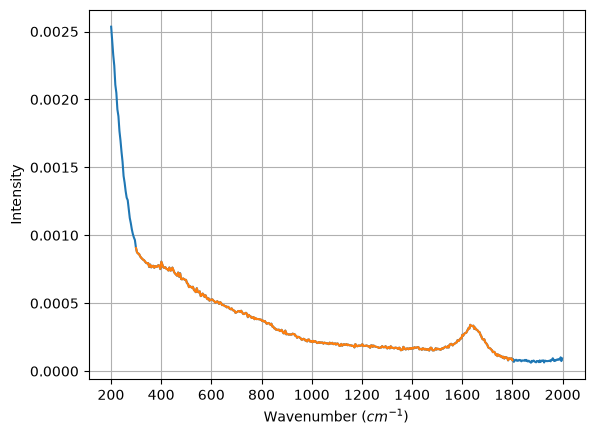

In [25]:
plt.plot(np.array(test_spectral_cols,dtype='float'),original_data)
plt.plot(fingerprint_grid,new_data)
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.xticks(np.arange(200,2200,step=200))
plt.grid()
plt.show()

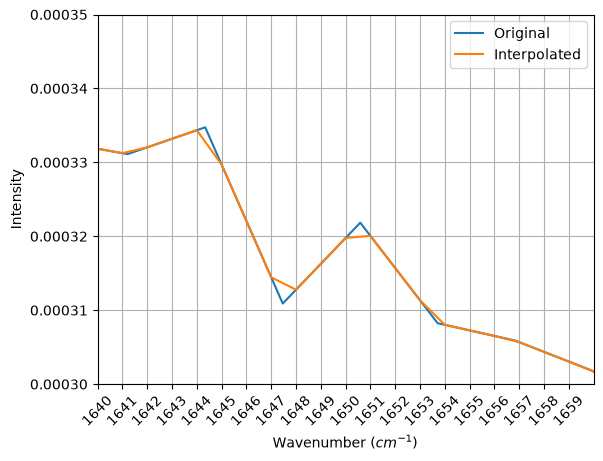

In [26]:
plt.plot(np.array(test_spectral_cols,dtype='float'),original_data,label='Original')
plt.plot(fingerprint_grid,new_data,label = 'Interpolated')
wn_range = (1640,1660)
plt.xlim(wn_range[0],wn_range[1])
plt.ylim(0.0003,0.00035)
plt.xticks(np.arange(wn_range[0],wn_range[1],1),rotation=45)
plt.grid()
plt.legend()
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.show()

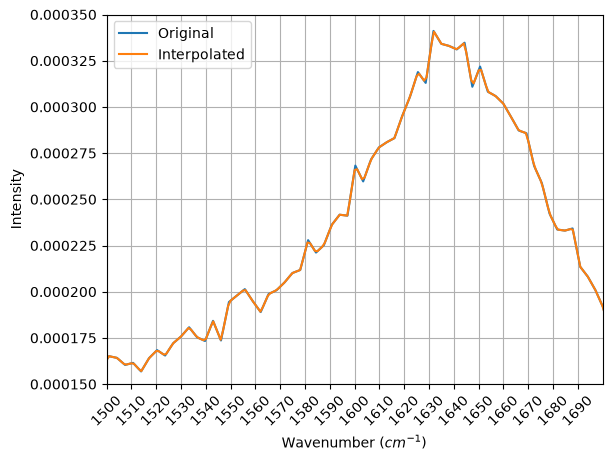

In [27]:
plt.plot(np.array(test_spectral_cols,dtype='float'),original_data,label='Original')
plt.plot(fingerprint_grid,new_data,label = 'Interpolated')
wn_range = (1500,1700)
plt.xlim(wn_range[0],wn_range[1])
plt.ylim(0.00015,0.00035)
plt.xticks(np.arange(wn_range[0],wn_range[1],10),rotation=45)
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.grid()
plt.legend()
plt.show()

In [28]:
## Linear interpolation works well even for timegate, the dataset with the most sparse wavenumber columns

In [29]:
## Can np.interpolate handle multiple rows at once?

try:
    np.interp(fingerprint_grid,np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[1:3].to_numpy())
except:
    print('Unsuccessful')

Unsuccessful


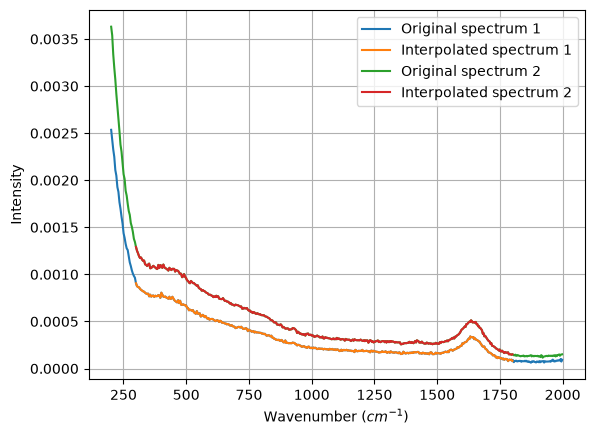

In [30]:
from scipy.interpolate import interp1d

def interpolate_spectra_to_grid(spectra: np.ndarray, old_wavenumbers: np.ndarray, new_wavenumbers: np.ndarray) -> np.ndarray:
    f = interp1d(
        old_wavenumbers,
        spectra,
        axis=1,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    return f(new_wavenumbers)

interpolated = interpolate_spectra_to_grid(test_spectral.iloc[:2], np.array(test_spectral_cols,dtype='float'),fingerprint_grid)

plt.plot(np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[0],label='Original spectrum 1')
plt.plot(fingerprint_grid,interpolated[0],label='Interpolated spectrum 1')
plt.plot(np.array(test_spectral_cols,dtype='float'),test_spectral.iloc[1],label='Original spectrum 2')
plt.plot(fingerprint_grid,interpolated[1],label='Interpolated spectrum 2')
plt.grid()
plt.legend()
plt.xlabel('Wavenumber $(cm^{-1})$')
plt.ylabel('Intensity')
plt.show()


## np interpolation can't handle multiple rows at once, but the scipy one can.

In [34]:
from dig4bio.preprocessing import interpolate_spectra_to_grid

interpolated_by_device = {}

for device, df in interim_dfs.items():
    spectral_cols = get_interim_spectral_cols(device,df)

    old_wavenumbers = np.array(spectral_cols, dtype=float)
    spectra = df[spectral_cols].to_numpy(dtype=float)
    
    interpolated_by_device[device] = interpolate_spectra_to_grid(
        spectra,
        old_wavenumbers = old_wavenumbers,
        new_wavenumbers = fingerprint_grid
    )

In [35]:
from dig4bio.preprocessing import build_wavenumber_grid
fingerprint_grid = build_wavenumber_grid()
old_96_spectrum_df = interim_dfs['96_samples'][get_interim_spectral_cols('96_samples',interim_dfs['96_samples'])]
display(pd.DataFrame(interpolated_by_device['96_samples'],columns = fingerprint_grid.astype(str)))
display(old_96_spectrum_df[old_96_spectrum_df.columns[147:]])

,300,301,302,303,304,305,306,307,308,309,...,1791,1792,1793,1794,1795,1796,1797,1798,1799,1800
0,9459.1250,9440.062112,9440.683230,9403.02500,9325.52500,9295.440994,9269.600,9239.6,9269.279503,9315.65000,...,1627.53125,1642.844720,1642.223602,1645.2,1650.819876,1671.316770,1689.71875,1705.34375,1696.142857,1672.2125
1,9441.6250,9411.422360,9435.645963,9429.93125,9393.05625,9312.714286,9256.075,9274.2,9299.850932,9323.63125,...,1640.06250,1653.049689,1641.248447,1644.2,1655.919255,1678.900621,1679.10000,1649.10000,1665.136646,1674.9625
2,8607.1875,8614.714286,8571.857143,8517.23125,8450.35625,8408.726708,8371.900,8339.4,8352.229814,8381.90000,...,1594.09375,1625.701863,1596.509317,1592.4,1603.565217,1642.695652,1666.07500,1668.57500,1651.987578,1625.0000
3,8560.0625,8553.944099,8543.385093,8527.58750,8506.33750,8434.900621,8377.950,8374.2,8410.590062,8458.28125,...,1602.03125,1623.291925,1616.459627,1612.0,1609.695652,1627.086957,1630.55000,1615.55000,1632.074534,1635.8375
4,9432.6875,9347.453416,9321.987578,9321.55625,9347.18125,9274.819876,9216.275,9224.4,9251.919255,9279.65625,...,1616.68750,1639.360248,1628.801242,1645.4,1677.118012,1705.068323,1704.33750,1665.58750,1693.024845,1707.9500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,9424.8750,9449.583851,9415.422360,9380.85000,9345.85000,9276.770186,9215.950,9187.2,9226.993789,9288.96875,...,1610.28125,1633.428571,1619.142857,1623.6,1638.571429,1652.857143,1652.13125,1631.50625,1642.950311,1645.8625
188,9286.9375,9219.875776,9218.633540,9176.35000,9091.35000,9072.602484,9057.475,9030.6,9054.521739,9094.01250,...,1592.56250,1598.981366,1590.906832,1602.8,1625.894410,1648.254658,1663.95625,1670.83125,1652.925466,1624.9625
189,9425.3750,9358.006211,9348.068323,9301.35000,9216.35000,9203.683230,9197.850,9186.6,9245.931677,9329.59375,...,1607.00000,1620.447205,1614.236025,1622.0,1638.242236,1669.298137,1678.40000,1658.40000,1670.981366,1669.5000
190,9433.0625,9367.043478,9297.478261,9233.82500,9176.32500,9134.068323,9090.300,9037.8,9117.720497,9246.71875,...,1620.84375,1648.080745,1616.403727,1606.2,1609.689441,1651.925466,1668.74375,1651.86875,1650.546584,1638.9375


,300.9,302.51,304.11,305.72,307.32,308.93,310.53,312.14,313.74,315.35,...,3335.56,3337.16,3338.77,3340.37,3341.98,3343.58,3345.19,3346.79,3348.4,3350.0
0,9440,9441,9317,9278,9230,9323,9155,9167,9124,9152,...,1709,1706,1598,1627,1653,1008,1035,1061,1282,5611
1,9409,9448,9389,9251,9280,9327,9250,9152,9191,9121,...,1668,1659,1594,1625,1656,1022,1020,1057,1301,5731
2,8619,8550,8443,8381,8329,8384,8336,8263,8253,8225,...,1650,1617,1544,1558,1617,1012,1012,1059,1295,5112
3,8555,8538,8504,8379,8373,8462,8377,8304,8311,8295,...,1629,1644,1551,1545,1559,1013,1036,1070,1274,5161
4,9350,9309,9350,9214,9227,9286,9141,9143,9124,9130,...,1687,1705,1602,1634,1620,1008,1016,1051,1278,5513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,9453,9398,9342,9224,9178,9294,9179,9073,9071,9057,...,1685,1701,1573,1638,1615,1037,1003,1039,1271,5402
188,9220,9218,9082,9065,9022,9099,8985,8859,8992,8915,...,1658,1690,1569,1585,1640,1001,1007,1043,1260,5863
189,9359,9343,9207,9201,9183,9332,9277,9070,9006,9122,...,1680,1678,1563,1607,1641,984,1002,1044,1241,5601
190,9374,9262,9170,9105,9021,9250,9175,9035,9134,9038,...,1679,1657,1553,1606,1631,994,991,1052,1272,5458


In [43]:
from dig4bio.constants import SOURCE_DEVICE_NAMES
from dig4bio.preprocessing import build_wavenumber_grid, interpolate_spectra_to_grid

interpolated_dfs = {}

source_device_dfs = read_raman_files(SOURCE_DEVICE_NAMES,level="interim")

fingerprint_wavenumber_grid = build_wavenumber_grid()

for device_name, df in source_device_dfs.items():
    
    df_copy = df.copy()

    spectral_columns = get_interim_spectral_cols(device_name, df_copy)

    spectra_df = df_copy[spectral_columns].to_numpy(dtype=float)

    labels_df = df_copy.drop(columns = spectral_columns)

    old_wavenumbers = np.array(spectral_columns,dtype=float)

    interpolated_spectra = interpolate_spectra_to_grid(
        spectra = spectra_df, 
        old_wavenumbers = old_wavenumbers,
        new_wavenumbers = fingerprint_wavenumber_grid
    )

    interpolated_df = pd.DataFrame(interpolated_spectra, columns = fingerprint_wavenumber_grid.astype(str), index=df.index)
    interpolated_df = pd.concat([interpolated_df,labels_df],axis=1)

    interpolated_dfs[device_name] = interpolated_df

interpolated_dfs['timegate']

,300,301,302,303,304,305,306,307,308,309,...,1796,1797,1798,1799,1800,glucose,Na_acetate,Mg_SO4,MSM_present,fold_idx
0,0.000906,0.000898,0.000889,0.000881,0.000875,0.000872,0.000870,0.000868,0.000866,0.000865,...,0.000094,0.000092,0.000086,0.000081,0.000080,0.000000,1.017310,0.000000,0.0,0
1,0.001290,0.001280,0.001270,0.001260,0.001251,0.001244,0.001238,0.001231,0.001224,0.001216,...,0.000147,0.000147,0.000148,0.000150,0.000150,0.270740,1.045500,0.000000,0.0,0
2,0.000651,0.000641,0.000631,0.000622,0.000615,0.000613,0.000612,0.000611,0.000609,0.000608,...,0.000078,0.000081,0.000083,0.000085,0.000085,0.000000,1.192280,0.000000,0.0,0
3,0.000470,0.000472,0.000474,0.000476,0.000477,0.000473,0.000469,0.000466,0.000461,0.000454,...,0.000062,0.000063,0.000064,0.000066,0.000066,0.257870,0.000000,0.000000,0.0,0
4,0.001421,0.001412,0.001403,0.001395,0.001387,0.001381,0.001375,0.001370,0.001363,0.001351,...,0.000164,0.000163,0.000160,0.000157,0.000158,4.778830,0.000000,0.023272,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,0.001054,0.001044,0.001033,0.001023,0.001015,0.001014,0.001013,0.001012,0.001010,0.001005,...,0.000120,0.000119,0.000120,0.000121,0.000120,0.346020,0.000000,0.000000,0.0,4
129,0.000893,0.000883,0.000873,0.000863,0.000855,0.000851,0.000848,0.000845,0.000842,0.000837,...,0.000124,0.000120,0.000113,0.000106,0.000105,0.000000,0.767730,3.945410,0.0,4
130,0.001640,0.001632,0.001624,0.001617,0.001609,0.001602,0.001594,0.001587,0.001580,0.001574,...,0.000462,0.000463,0.000467,0.000471,0.000474,6.459915,0.109961,0.000000,1.0,4
131,0.001789,0.001786,0.001784,0.001781,0.001774,0.001754,0.001735,0.001716,0.001700,0.001696,...,0.000240,0.000240,0.000238,0.000236,0.000235,10.161200,0.000000,1.477840,0.0,4


In [46]:
from dig4bio.io import read_raman_file

combined_df = read_raman_file('source_datasets.csv',level='processed',subfolder='source_grid_fingerprint_linear')
display(combined_df.columns)
display(combined_df.sample(10))

Index(['300', '301', '302', '303', '304', '305', '306', '307', '308', '309',
       ...
       '1797', '1798', '1799', '1800', 'glucose', 'Na_acetate', 'Mg_SO4',
       'MSM_present', 'fold_idx', 'device'],
      dtype='str', length=1507)

,300,301,302,303,304,305,306,307,308,309,...,1797,1798,1799,1800,glucose,Na_acetate,Mg_SO4,MSM_present,fold_idx,device
548,4334.310200,4325.129167,4312.304067,4296.190700,4278.394833,4261.085100,4245.852800,4233.210900,4222.176800,4211.146600,...,528.218573,528.464112,530.994833,531.864525,0.27074,1.04550,0.00000,0.0,0,kaiser
321,947.020000,948.710000,950.400000,949.875000,949.350000,947.790000,946.230000,946.210000,946.190000,944.545000,...,784.785000,783.080000,779.260000,775.440000,0.00000,1.29106,0.00000,0.0,1,anton785
2112,38675.041330,38516.931462,38416.447558,38329.643683,38228.579109,38093.406842,37940.170722,37801.133991,37698.430399,37644.383323,...,5155.553762,5111.035821,5100.926732,5135.966870,10.28120,0.66554,0.00000,0.0,3,tornado
584,3920.139200,3906.962367,3898.941367,3894.417800,3890.132767,3883.360067,3873.515600,3862.007033,3850.968467,3841.577300,...,530.966917,530.798480,529.949169,527.376903,2.47352,1.09935,0.05154,0.0,1,kaiser
517,1011.170000,1013.140000,1015.110000,1007.455000,999.800000,998.525000,997.250000,999.675000,1002.100000,1003.335000,...,799.710000,807.690000,801.465000,795.240000,0.24955,0.08245,3.45439,0.0,4,anton785
1051,3535.502146,3557.547414,3500.219828,3442.892241,3435.128755,3438.991416,3453.000000,3478.000000,3500.442060,3509.454936,...,1321.134503,1307.647059,1269.411765,1282.894737,1.96857,0.73647,0.00000,0.0,4,metrohm
9,3031.860000,3035.085000,3038.310000,3035.800000,3033.290000,3012.935000,2992.580000,2961.830000,2931.080000,2915.075000,...,1210.045000,1210.350000,1194.030000,1177.710000,10.65220,0.00000,2.62021,0.0,0,anton532
1100,13688.655807,13728.511099,13757.942744,13775.383168,13782.443754,13788.478299,13822.652922,13906.975332,14011.956268,14100.041258,...,2879.748238,2891.778614,2853.844931,2816.055079,0.00000,1.37442,1.35580,0.0,0,mettler
1305,7058.999898,7034.037850,7010.898693,7003.826104,7001.455017,6993.829756,6980.179166,6962.912649,6952.754303,6960.318955,...,840.773907,844.523917,832.499647,829.916615,0.51645,1.02701,1.32862,0.0,4,mettler
1524,2353.199236,2376.307596,2344.596451,2297.973303,2242.516379,2116.752380,2125.354801,2189.631652,2304.146619,2562.025686,...,3375.856038,3375.103167,3367.168958,3359.523511,2.93703,1.43376,0.00000,0.0,2,tec
